# 1. EDA

In [35]:
import random
import re
from pathlib import Path
from typing import Tuple, Dict, List

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
import torchvision.transforms.functional as TF
from torch.cuda.amp import autocast, GradScaler # Quan trọng để tránh OOM

from tqdm.auto import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Data Augmentation

In [36]:
class VideoTransform:
    def __init__(self, mode="train", img_size=224):
        self.is_train = (mode=='train')
        self.image_size = img_size
        self.mean = [0.485, 0.456, 0.406]
        self.std = [0.229, 0.224, 0.225]

    def __call__(self, frames: torch.Tensor) -> torch.Tensor:
        # frames: [T, C, H, W]
        if self.is_train:
            # random r3siz3d crop
            h, w = frames.shape[-2:]
            scale = random.uniform(0.8, 1.0)
            new_h, new_w = int(h*scale), int(w*scale)
            frames = TF.resize(frames, [new_h, new_w], interpolation=transforms.InterpolationMode.BILINEAR)

            # random crop
            i = random.randint(0, max(0, new_h - self.image_size))
            j = random.randint(0, max(0, new_w - self.image_size))
            frames = TF.crop(frames, i, j, min(self.image_size, new_h), min(self.image_size, new_w))
            frames = TF.resize(frames, [self.image_size, self.image_size], interpolation=transforms.InterpolationMode.BILINEAR)

            # horizontal flip (left <--> right)
            if random.random() < 0.5:
                frames = TF.hflip(frames)

        else: #val
            frames = TF.resize(frames, [self.image_size, self.image_size], interpolation=transforms.InterpolationMode.BILINEAR)

        normalized = [TF.normalize(frame, self.mean, self.std) for frame in frames]
        return torch.stack(normalized)

In [37]:
%ls hmdb51_data/brush_hair/April_09_brush_hair_u_nm_np1_ba_goo_1/

ls: cannot access 'hmdb51_data/brush_hair/April_09_brush_hair_u_nm_np1_ba_goo_1/': No such file or directory


In [38]:
class HMDB51Dataset(Dataset):
    def __init__(self, root: str, split: str, num_frames: int = 16, frame_stride: int = 1,
                 image_size: int = 224, val_ratio: float = 0.1, seed: int = 42):
        super().__init__()

        self.root = Path(root)
        if not self.root.is_dir():
            raise FileNotFoundError(f"Data root not found: {self.root}")

        self.classes = sorted([d.name for d in self.root.iterdir() if d.is_dir()])
        if not self.classes:
            raise RuntimeError(f"No class folders in {self.root}")

        self.class_to_id = {name: id for id, name in enumerate(self.classes)}

        # group videos by (class, base_video_name)
        grouped_samples: Dict[Tuple[str, str], List[Tuple[List[Path], int]]] = {}
        for cls in self.classes:
            cls_dir = self.root / cls
            for video_dir in sorted([d for d in cls_dir.iterdir() if d.is_dir()]):
                frame_paths = sorted([p for p in video_dir.iterdir() if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])
                if not frame_paths:
                    continue
                group_key = (cls, self._base_video_name(video_dir.name))
                grouped_samples.setdefault(group_key, []).append((frame_paths, self.class_to_id[cls]))

        if not grouped_samples:
            raise RuntimeError(f"No frame folders found inside {self.root}")

        # split groups
        group_values = list(grouped_samples.values())
        rng = np.random.RandomState(seed)
        group_indices = np.arange(len(group_values))
        rng.shuffle(group_indices)
        split_point = int(len(group_indices) * (1-val_ratio))

        if split == "train":
            selected_groups = group_indices[:split_point]
        elif split in ["val", "test"]:
            selected_groups = group_indices[split_point:]
        else:
            raise ValueError(f"Unknown split: {split}")

        samples: List[Tuple[List[Path], int]] = []

        for id in selected_groups:
            samples.extend(group_values[int(id)])

        if not samples:
            raise RuntimeError(f"Selected split has no samples, adjust ratio or check data folders")

        self.samples = samples
        self.split = split
        self.num_frames = num_frames
        self.frame_stride = max(1, frame_stride)
        self.transform = VideoTransform(mode="train" if split == "train" else "val", img_size=image_size)
        self.to_tensor = transforms.ToTensor()

    def __len__(self) -> int:
        return len(self.samples)

    def _select_indices(self, total: int) -> torch.Tensor:
        if total <= 0:
            raise ValueError("Video folder has no frames")

        if total == 1:
            return torch.zeros(self.num_frames, dtype=torch.long)

        steps = max(self.num_frames*self.frame_stride, self.num_frames)
        grid = torch.linspace(0, total-1, steps=steps)
        ids = grid[:: self.frame_stride].long()

        if ids.numel() < self.num_frames:
            pad = ids.new_full((self.num_frames - ids.numel(),), ids[-1].item())
            ids = torch.cat([ids, pad], dim=0)

        return ids[:self.num_frames]

    @staticmethod
    def _base_video_name(name: str) -> str:
        match = re.match(r"(.+)_\d+$", name)
        return match.group(1) if match else name

    def __getitem__(self, id: int) -> Tuple[torch.Tensor, int]:
        frame_paths, label = self.samples[id]
        total = len(frame_paths)
        ids = self._select_indices(total)

        frames = []
        for i in ids:
            path = frame_paths[int(i.item())]
            with Image.open(path) as img:
                img = img.convert("RGB")
                frames.append(self.to_tensor(img))

        video = torch.stack(frames)
        video = self.transform(video)
        return video, label

def collate_fn(batch: List[Tuple[torch.Tensor, int]]) -> Tuple[torch.Tensor, torch.Tensor]:
    videos = torch.stack([item[0] for item in batch])
    labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
    return videos, labels

## LOAD DATASET

In [39]:
DATA_ROOT = '/kaggle/input/datasets/midzid/hmdb51/hmdb51_data'
VAL_RATIO = 0.1
SEED=42
NUM_FRAMES=16
FRAME_STRIDE=2
IMG_SIZE=224
BATCH_SIZE=4
NUM_WORKERS=4

In [40]:
train_dataset = HMDB51Dataset(
    root=DATA_ROOT,
    split="train",
    num_frames=NUM_FRAMES,
    frame_stride=FRAME_STRIDE,
    image_size=IMG_SIZE,
    val_ratio=VAL_RATIO,
    seed=SEED,
)

val_dataset = HMDB51Dataset(
    root=DATA_ROOT,
    split="val",
    num_frames=NUM_FRAMES,
    frame_stride=FRAME_STRIDE,
    image_size=IMG_SIZE,
    val_ratio=VAL_RATIO,
    seed=SEED,
)

In [41]:
print(f"Train clips: {len(train_dataset)}")
print(f"Train Class count: {len(train_dataset.classes)}")

print(f"Val clips: {len(val_dataset)}")
print(f"Val Class count: {len(val_dataset.classes)}")

Train clips: 6121
Train Class count: 51
Val clips: 645
Val Class count: 51


In [42]:
sample_vid, sample_label = train_dataset[0]
print(f"Train sample: {sample_vid.shape} - {train_dataset.classes[sample_label]}")

Train sample: torch.Size([16, 3, 224, 224]) - catch


In [43]:
sample_vid, sample_label = val_dataset[0]
print(f"Val sample: {sample_vid.shape} - {val_dataset.classes[sample_label]}")

Val sample: torch.Size([16, 3, 224, 224]) - smoke


## DATALOADER

In [44]:
train_loader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True,
                          num_workers=NUM_WORKERS,
                          collate_fn=collate_fn)

val_loader = DataLoader(val_dataset,
                        BATCH_SIZE,
                        shuffle=False,
                        num_workers=NUM_WORKERS,
                        collate_fn=collate_fn)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 1531
Val batches: 162


# TSM

In [45]:
import torchvision.models as models

class TemporalShift(nn.Module):
    def __init__(self, net, n_segment=16, n_div=8):
        super(TemporalShift, self).__init__()
        self.net = net
        self.n_segment = n_segment # Số lượng frames trong 1 video (của bạn là 16)
        self.n_div = n_div # Tỉ lệ channel dùng để dịch chuyển (thường là 1/8)

    def forward(self, x):
        # x có shape: [Batch * Time, Channel, H, W]
        bt, c, h, w = x.size()
        t = self.n_segment
        b = bt // t
        x = x.view(b, t, c, h, w) # Tách ra thành [B, T, C, H, W]

        fold = c // self.n_div
        out = torch.zeros_like(x)
        
        # Cơ chế Shift: Dịch khung hình về trước và sau để trao đổi thông tin
        out[:, :-1, :fold] = x[:, 1:, :fold]         # Shift sang trái (Past)
        out[:, 1:, fold:2*fold] = x[:, :-1, fold:2*fold] # Shift sang phải (Future)
        out[:, :, 2*fold:] = x[:, :, 2*fold:]        # Giữ nguyên phần còn lại
        
        return self.net(out.view(bt, c, h, w))

def make_tsm_resnet50(num_classes, n_segment=16):
    # Dùng ResNet-50 pre-trained để học nhanh hơn
    base_model = models.resnet50(weights='IMAGENET1K_V1')
    
    # "Phẫu thuật" chèn TSM vào các khối Bottleneck của ResNet
    def add_tsm(model):
        for name, child in model.named_children():
            if isinstance(child, models.resnet.Bottleneck):
                child.conv1 = TemporalShift(child.conv1, n_segment=n_segment)
            else:
                add_tsm(child)
    
    add_tsm(base_model)
    
    # Thay đổi lớp phân loại cuối cùng cho 51 lớp của HMDB51
    base_model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(base_model.fc.in_features, num_classes)
    )
    return base_model

In [46]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        # Sử dụng torch.amp.autocast thay vì bản cũ để hết cảnh báo
        pbar = tqdm(dataloader, desc="Validating....")
        for videos, labels in pbar:
            videos, labels = videos.to(device), labels.to(device)

            with torch.amp.autocast('cuda'):
                outputs = model(videos)
                loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

            pbar.set_postfix({'loss': f'{total_loss / (pbar.n + 1):.4f}',
                             'acc': f'{correct / total:.4f}'})

    return total_loss / len(dataloader), correct / total

In [47]:
class TSM_Network(nn.Module):
    def __init__(self, num_classes=51, n_segment=16):
        super().__init__()
        # Khởi tạo backbone ResNet-50 đã được chèn các lớp Temporal Shift
        self.model = make_tsm_resnet50(num_classes, n_segment)

    def forward(self, x):
        # x shape: [Batch, Time, Channel, H, W] -> (Ví dụ: [4, 16, 3, 224, 224])
        b, t, c, h, w = x.shape
        
        # Bước 1: Ép Batch và Time lại để ResNet 2D có thể đọc được
        # New shape: [Batch * Time, Channel, H, W] -> ([64, 3, 224, 224])
        x = x.view(b * t, c, h, w)
        
        # Bước 2: Chạy qua mạng ResNet-50 (đã có TSM trao đổi thông tin giữa các frames)
        logits = self.model(x) # Output shape: [64, 51] (51 là số lớp hành động)
        
        # Bước 3: Tách lại Batch và Time, sau đó lấy trung bình theo chiều Time (dim=1)
        # logits.view(b, t, -1) -> [4, 16, 51]
        # .mean(dim=1) -> [4, 51] (Kết quả cuối cùng cho 4 video)
        return logits.view(b, t, -1).mean(dim=1)

In [48]:
from torch.cuda.amp import autocast, GradScaler

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    scaler = GradScaler() # Khởi tạo bộ scale gradient cho FP16
    total_loss, correct, total = 0, 0, 0
    
    pbar = tqdm(dataloader, desc="Training TSM...")
    for videos, labels in pbar:
        videos, labels = videos.to(device), labels.to(device)

        optimizer.zero_grad()
        
        # Sử dụng autocast để tiết kiệm bộ nhớ
        with autocast():
            outputs = model(videos)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward() # Backward với dữ liệu nén FP16
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
        
    return total_loss/len(dataloader), correct/total

In [49]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = TSM_Network(num_classes=len(train_dataset.classes), n_segment=NUM_FRAMES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())

print(f"   Model created")
print(f"   Total parameters: {total_params:,} ({total_params/1e6:.2f}M)")
print(f"   Architecture: ViT-Base from scratch")
print(f"   Status: Untrained (from scratch)")

   Model created
   Total parameters: 23,612,531 (23.61M)
   Architecture: ViT-Base from scratch
   Status: Untrained (from scratch)


## Training

Train Function

In [50]:
def denormalize(frames):
    """Denormalize for visualizing"""
    frames = frames.clone()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1) # mean & std of ImageNet
    std = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)
    frames = frames * std + mean
    return frames.clamp(0,1)

Train Setup

In [51]:
EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5

optimizer = torch.optim.Adam(model.parameters(),
                             lr=LEARNING_RATE,
                             weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Training setup:")
print(f"   Epochs: {EPOCHS}")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Trainable parameters: {trainable_params:,} (ALL params)")
print(f"   Optimizer: Adam")
print(f"   Scheduler: CosineAnnealing")

   Training setup:
   Epochs: 20
   Learning rate: 0.0001
   Trainable parameters: 23,612,531 (ALL params)
   Optimizer: Adam
   Scheduler: CosineAnnealing


TRAININGGGG

In [52]:
import time

In [53]:
start = time.time()
for i in range(1000):
    continue
time.time() - start

0.00016808509826660156

In [54]:
history = {'train_loss': [], 'train_acc': [],
           'val_loss': [], 'val_acc': [],
           'train_time': []}
best_acc = 0.0
best_model_path = 'tsm_resnet50_best.pt'

print(f"\n{'='*63}")
print(f"Fine-tuning BasicViT for {EPOCHS} epochs")
print(f"\n{'='*63}")


for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    duration = time.time() - start

    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)


    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['train_time'].append(duration)

    print(f"  -Train: Loss={train_loss:.4f}, Acc={train_acc:.4f}")
    print(f"  -Val:   Loss={val_loss:.4f}, Acc={val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"    Best model saved with acc = {best_acc:.4f}")

    scheduler.step()

print(f"\n{'='*63}")
print(f"Training complete!")
print(f"Best val accuracy: {best_acc:.4f}")
print(f"\n{'='*63}")



Fine-tuning BasicViT for 20 epochs

Epoch 1/20


/tmp/ipykernel_57/3921501724.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() # Khởi tạo bộ scale gradient cho FP16


Training TSM...:   0%|          | 0/1531 [00:00<?, ?it/s]

/tmp/ipykernel_57/3921501724.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Validating....:   0%|          | 0/162 [00:00<?, ?it/s]

...

Validating....:   0%|          | 0/162 [00:00<?, ?it/s]

  -Train: Loss=0.1371, Acc=0.9686
  -Val:   Loss=1.9250, Acc=0.6233
Epoch 20/20


Training TSM...:   0%|          | 0/1531 [00:00<?, ?it/s]

Validating....:   0%|          | 0/162 [00:00<?, ?it/s]

  -Train: Loss=0.1310, Acc=0.9688
  -Val:   Loss=1.9169, Acc=0.6109

Training complete!
Best val accuracy: 0.6279



## Plot results

Plot saved!


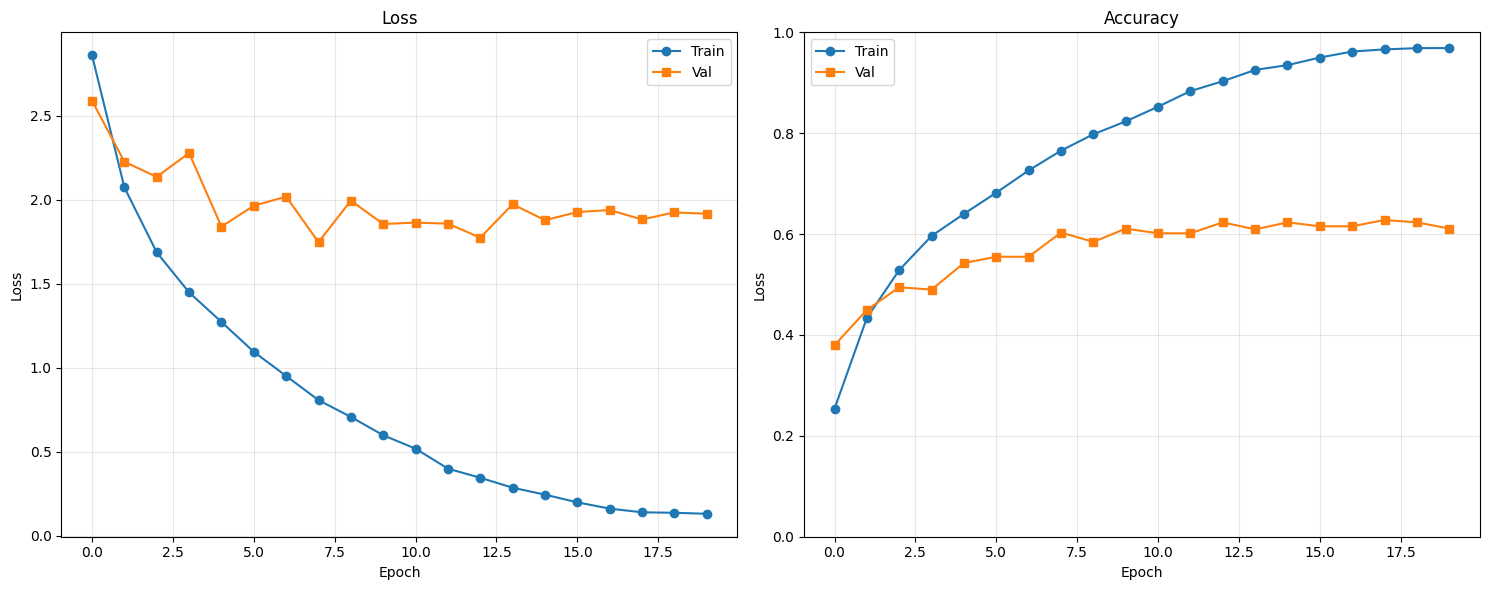

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))

# plot loss
axes[0].plot(history['train_loss'], label='Train', marker = 'o')
axes[0].plot(history['val_loss'], label='Val', marker='s')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# plot accuracy
axes[1].plot(history['train_acc'], label='Train', marker = 'o')
axes[1].plot(history['val_acc'], label='Val', marker='s')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0,1])

plt.tight_layout()
plt.savefig("tsm_training_results.png", dpi=100, bbox_inches='tight')
print("Plot saved!")
plt.show()